# Chapter 5. Tool Use

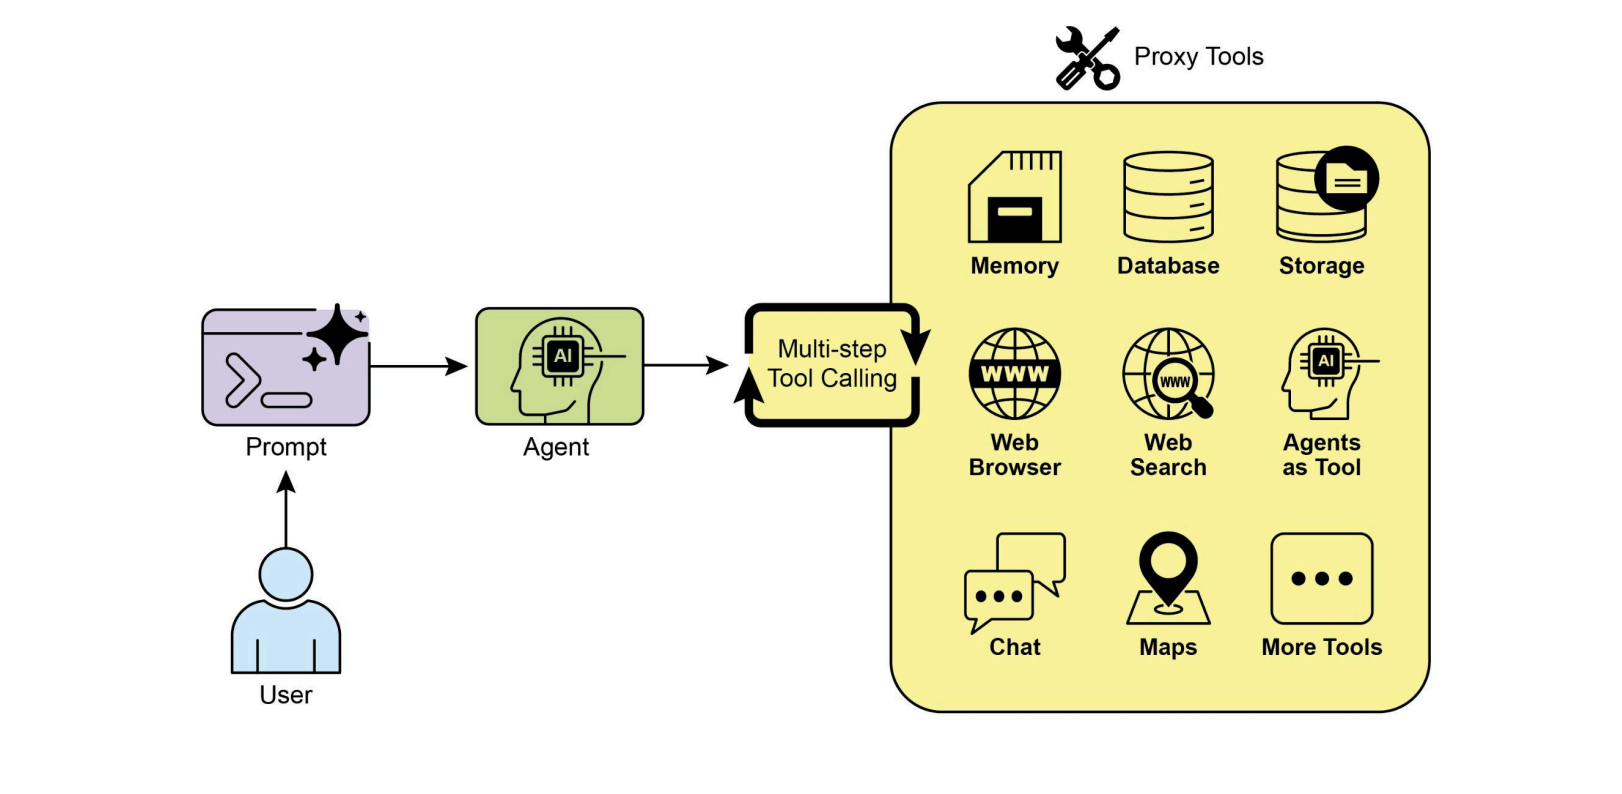

### Core Concept
- **Real-World Interaction**: Enables agents to interact with external APIs, databases, services, or even execute code.
- **Beyond Training Data**: Breaks the limitations of the model's static training by allowing it to access current, real-time information.
- **Function Calling**: The technical mechanism where an LLM generates structured data (like a JSON object) to specify which external tool to use and what arguments to send to it.

### The Process
1. **Define**: Clearly describe the tool’s name, purpose, and parameters to the LLM
2. **Decide**: The LLM receives the user's request and available tool definitions to determine if calling a tool is necessary.
3. **Generate**: The model creates a structured request with the arguments needed for the tool.
4. **Execute**: The framework intercepts the request, runs the actual function, and gets a result.
5. **Observe & Respond**: The agent receives the tool's output as context to provide a final answer or decide on the next step.

### Why Use It?
- **Up-to-Date Info**: Get current weather, stock prices, or news that the model doesn't know internally.
- **Precise Calculations**: Offload complex math or data analysis to external calculators to ensure accuracy.
- **Taking Action**: Allow the agent to "do" things, such as sending emails or controlling smart home devices.

### Hands-on Code Example

First, ensure you have the necessary libraries installed:
```
pip install langchain langchain-community langchain-openai
```

In [1]:
import os, logging
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool as langchain_tool
from langchain_classic.agents import create_tool_calling_agent, AgentExecutor, tool
from typing import List
from dotenv import load_dotenv, find_dotenv
from IPython.display import display, Markdown

load_dotenv(find_dotenv(usecwd=True))
API_KEY  = os.environ.get("API_KEY")
BASE_URL = os.environ.get("BASE_URL")

Initialize the Language Model.

In [2]:
llm = ChatOpenAI(
    model="glm-5-turbo",
    api_key=API_KEY,
    base_url=BASE_URL,
    temperature=0
)

Define a tool.

In [3]:
@tool
def search_information(query: str) -> str:
    """
    Provides factual information on a given topic. 
    Use this tool to find answers to phrases like 'capital of France' or 'weather in London?'.
    """
    print(f"\n--- ️ Tool Called: search_information with query: '{query}' ---")
    
    simulated_results = {
        "weather in london": "The weather in London is currently cloudy with a temperature of 15°C.",
        "capital of france": "The capital of France is Paris.",
        "population of earth": "The estimated population of Earth is around 8 billion people.",
        "tallest mountain": "Mount Everest is the tallest mountain above sea level.",
        "default": f"Simulated search result for '{query}': No specific information found, but the topic seems interesting."
    }

    result = simulated_results.get(query.lower(), simulated_results["default"])
    print(f"--- TOOL RESULT: {result} ---")
    
    return result

Create a Tool-Calling Agent.

- `create_tool_calling_agent`: a function used to initialize an agent that leverages native tool-calling features built directly into modern language models.
- `AgentExecutor`: the legacy runtime environment that orchestrates the execution loop for an AI agent, coordinating how large language models (LLMs) interact with external tools.

In [4]:
tools = [search_information]

agent_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
])

agent          = create_tool_calling_agent(llm, tools, agent_prompt)
agent_executor = AgentExecutor(agent=agent, verbose=False, tools=tools)

In [5]:
async def run_agent_with_tool(query: str):
    """Invokes the agent executor with a query and prints the final response."""
    
    print(f"\n--- 🏃 Running Agent with Query: '{query}' ---")
    
    try:
        response = await agent_executor.ainvoke({"input": query})
        print("\n--- ✅ Final Agent Response ---")
        display(Markdown(response["output"]))
        
    except Exception as e:
        print(f"\n🛑 An error occurred during agent execution: {e}")

Runs all agent queries.

In [6]:
await run_agent_with_tool("What is the capital of France?")


--- 🏃 Running Agent with Query: 'What is the capital of France?' ---

🛑 An error occurred during agent execution: Connection error.


In [7]:
await run_agent_with_tool("What's the weather like in London?")


--- 🏃 Running Agent with Query: 'What's the weather like in London?' ---

🛑 An error occurred during agent execution: Connection error.


In [8]:
await run_agent_with_tool("Tell me something about dogs.")


--- 🏃 Running Agent with Query: 'Tell me something about dogs.' ---

🛑 An error occurred during agent execution: Connection error.


### Practical Applications & Use Cases
1. Information Retrieval from External Sources:
   Accessing real-time data or information that is not present in the LLM's training data.

    - **Use Case**: A weather agent
    - **Tool**: A weather API that takes a location and returns the current weather conditions.
    - **Agent Flow**: User asks, "What's the weather in `location`?", LLM identifies the
    need for the weather tool, calls the tool with `location`, tool returns data, LLM
    formats the data into a user-friendly response.

Please get your `WEATHER_API_KEY` from <a href="https://openweathermap.org/">https://openweathermap.org/</a>. Then, add the following in your `.env`.

```
OPENWEATHER_API_KEY = <YOUR_API_KEY>
```

In [33]:
import requests

OPENWEATHER_API_KEY = os.environ.get("OPENWEATHER_API_KEY")

Define a `coordinate_tool` to convert the string location into coordinate requires by the OpenWeather API.

In [34]:
@tool
def coordinates_tool(location: str) -> tuple:
    """
    Get the latitude and longitude for a given location name.
    Use this tool whenever you have a city/place name (not coordinates) and need coordinates before calling get_weather.
    
    Args:
        location: The name of the city/place, e.g. "London" or "Paris, France".

    Returns:
        coordinates: (langtitude, longtitude).
    """
    
    try:
        geo_url    = "http://api.openweathermap.org/geo/1.0/direct"
        geo_params = {
            "q": location,
            "limit": 1,
            "appid": OPENWEATHER_API_KEY,
        }
        response = requests.get(geo_url, params=geo_params, timeout=10)
        response.raise_for_status()
        result = response.json()
        
        coordinates = (result[0]["lat"], result[0]["lon"])
        return coordinates
        
    except (KeyError, IndexError) as e:
        return f"Sorry, I received an unexpected response format for '{location}'."

Define a `weather_tool` to get the temperature from the OpenWeather API.

In [35]:
@tool
def weather_tool(coordinates: tuple) -> str:
    """
    Get the current weather conditions for a given location. 
    Use this tool whenever the user asks about weather, temperature, or outdoor conditions for a specific city or place.
    
    Args:
        coordinates: (langtitude, longtitude).

    Returns:
        A int celcius describing the current weather.
    """

    try:
        lat, lon = coordinates
        weather_url = "https://api.openweathermap.org/data/2.5/weather"
        weather_params = {
            "lat": lat,
            "lon": lon,
            "units": "metric",
            "lang": "en",
            "appid": OPENWEATHER_API_KEY,
        }
        response = requests.get(weather_url, params=weather_params, timeout=10)
        response.raise_for_status()
        result = response.json()
        
        temperature = result["main"]["temp"]
        return temperature

    except requests.exceptions.RequestException as e:
        return f"Sorry, I couldn't retrieve the weather for '{coordinates}' due to a network/API error."


Create a Tool-Calling agent.

In [39]:
tools = [coordinates_tool, weather_tool]

agent_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}"),
])

agent          = create_tool_calling_agent(llm, tools, agent_prompt)
agent_executor = AgentExecutor(agent=agent, verbose=True, tools=tools)

In [40]:
async def run_agent_with_tool(query: str):
    """Invokes the agent executor with a query and prints the final response."""
    
    print(f"\n--- 🏃 Running Agent with Query: '{query}' ---")
    
    try:
        response = await agent_executor.ainvoke({"input": query})
        print("\n--- ✅ Final Agent Response ---")
        display(Markdown(response["output"]))
        
    except Exception as e:
        print(f"\n🛑 An error occurred during agent execution: {e}")

In [41]:
await run_agent_with_tool("What is the current weather in London?")


--- 🏃 Running Agent with Query: 'What is the current weather in London?' ---


> Entering new AgentExecutor chain...

Invoking: `coordinates_tool` with `{'location': 'London'}`
responded: I'll help you find the current weather in London! Let me first get the coordinates for London.

(51.5074456, -0.1277653)
Invoking: `weather_tool` with `{'coordinates': [51.5074456, -0.1277653]}`
responded: Now let me get the weather for those coordinates.

17.55The current weather in **London** is **17.55°C** (approximately 64°F). It's a mild and comfortable temperature — great for being outdoors! 🌤️

> Finished chain.

--- ✅ Final Agent Response ---


The current weather in **London** is **17.55°C** (approximately 64°F). It's a mild and comfortable temperature — great for being outdoors! 🌤️

In [42]:
await run_agent_with_tool("What is the current weather in (51.5074456, -0.1277653)?")


--- 🏃 Running Agent with Query: 'What is the current weather in (51.5074456, -0.1277653)?' ---


> Entering new AgentExecutor chain...

Invoking: `weather_tool` with `{'coordinates': [51.5074456, -0.1277653]}`


17.55The current weather at coordinates **(51.5074456, -0.1277653)** — which corresponds to **London, UK** — is **17.55°C** (approximately 64°F). It's a mild and comfortable temperature!

> Finished chain.

--- ✅ Final Agent Response ---


The current weather at coordinates **(51.5074456, -0.1277653)** — which corresponds to **London, UK** — is **17.55°C** (approximately 64°F). It's a mild and comfortable temperature!